In [1]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=11)

cifar_train = tds.CIFAR10(
    root='datasets',
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root='datasets',
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


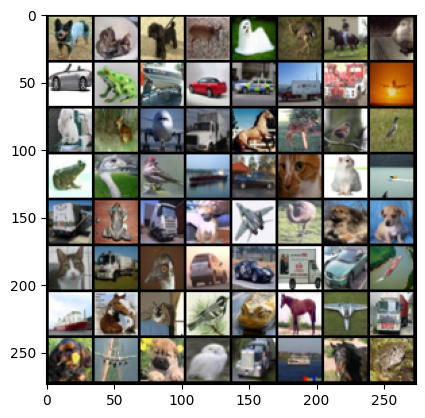

In [3]:
def random_grid(imgs, sz: int):
    samples_ix = torch.randint(low=0, high=len(imgs) - 1, size=(sz,))
    samples = imgs[samples_ix]
    grid = tu.make_grid(samples)
    return grid.permute(1, 2, 0)

tmps = torch.from_numpy(cifar_train.data)
tmps = random_grid(tmps.permute(0, 3, 1, 2), 64)
plt.imshow(tmps)

In [4]:
batchsize = 128

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [5]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = x.reshape(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        x = F.softmax(x, dim=-1)
        return x

class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (16x16)
        self.lin1 = nn.Linear(ch*2 * 16 * 16, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*2 * 16 * 16)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.softmax(x, dim=-1)
        return x
        

In [6]:
from torchinfo import summary
testmodel = MyCnn(out_sz=11, ch=16)
# testmodel = MyNn(3 * 32 * 32, 11, hidden_sz=512)
test = cifar_train[0][0].float()
target = cifar_train[0][1].float()
print(target, testmodel(test))
summary(testmodel, (1, 3, 32, 32))

tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]) tensor([[1.5667e-06, 7.5911e-05, 1.6473e-11, 3.8820e-07, 1.9753e-07, 2.4570e-09,
         1.9636e-08, 2.0257e-11, 9.9888e-01, 1.0450e-03, 4.6924e-12]],
       grad_fn=<SoftmaxBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [1, 11]                   --
├─Conv2d: 1-1                            [1, 16, 32, 32]           448
├─Conv2d: 1-2                            [1, 32, 32, 32]           4,640
├─Linear: 1-3                            [1, 128]                  1,048,704
├─Linear: 1-4                            [1, 11]                   1,419
Total params: 1,055,211
Trainable params: 1,055,211
Non-trainable params: 0
Total mult-adds (M): 6.26
Input size (MB): 0.01
Forward/backward pass size (MB): 0.39
Params size (MB): 4.22
Estimated Total Size (MB): 4.63

2.2121455669403076
2.1700422763824463
2.15480375289917
2.1340818405151367
2.1259782314300537
2.1124448776245117
2.1146864891052246
2.089224100112915
2.0844762325286865
2.081120491027832
2.078939199447632
2.0980021953582764
2.067408323287964
2.046116590499878
2.0469284057617188
2.0281834602355957
2.028446674346924
2.053708553314209
2.01987361907959
2.0171217918395996
2.0245556831359863
2.0125718116760254
2.0116655826568604
2.0226261615753174
2.0069363117218018
1.9962077140808105
2.0020852088928223
1.992347240447998
1.986937165260315
1.9945183992385864
CPU times: user 10min 47s, sys: 559 ms, total: 10min 48s
Wall time: 1min 11s


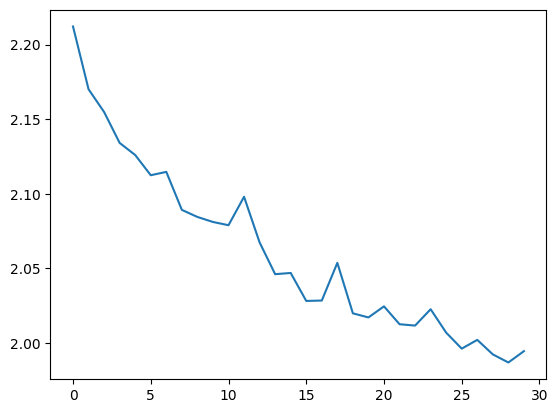

In [7]:
%%time
device='cuda'
# model = MyNn(3 * 32 * 32, 11, hidden_sz=512).to(device)
model = MyCnn(out_sz=11, ch=16).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.CrossEntropyLoss()
epochs = 30

loss_plot = []
for epoch in range(epochs):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 11))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 11))
            losses.append(loss)
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

In [8]:
total = len(cifar_eval)
correct = 0
with torch.no_grad():
    for image, target in cifar_eval:
        pred = model(image.float().to(device))
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

54.29% correct
